**Note: You need to add necessary comments in your code to enhance readability, as code readability is also one of the grading criteria.**

# **(Bonus: 10 points)** Data preprocessing 

## **(Bonus: 5 points)** ploting real waveform 

Plot the entire raw waveform **RealWaveform**. You will notice a low frequency component in the signal, known as the local field potential (LFP). We are not interested in analyzing the LFP during spike sorting. We remove the LFP using a high-pass filter, stopping frequencies below 250 Hz. (The result is already provided but you can try to implement this step by yourself using FFT in Python)

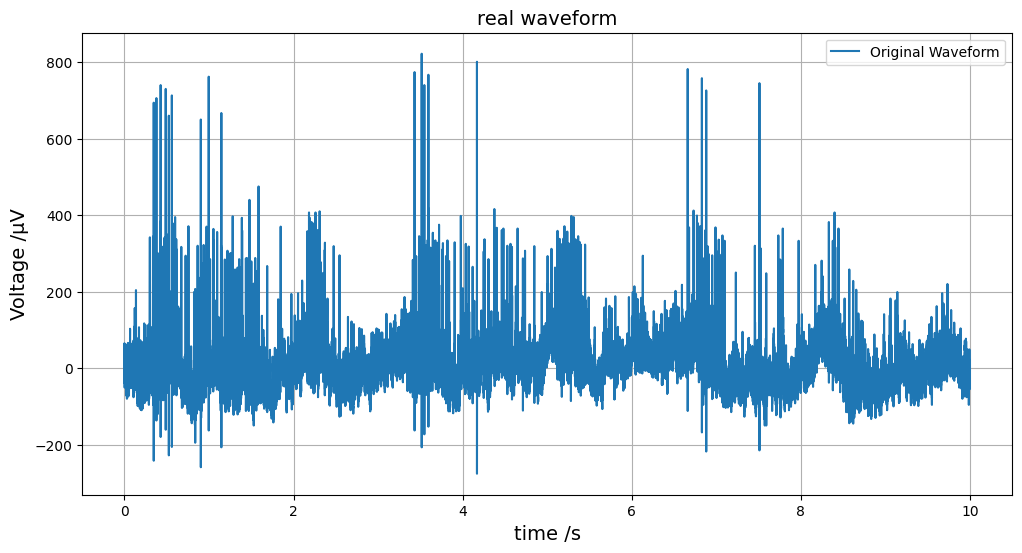

In [120]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat


plt.figure(figsize=(12, 6))
plt.grid(True)

# Load the .mat file
data = loadmat('ps2_data.mat')  # you can change your path here
RealWaveform = data['RealWaveform'].flatten()

# ================= write your code below ================== #

# 绘制原始波形
plt.plot(np.arange(len(RealWaveform)) / fs, RealWaveform, label='Original Waveform')
plt.legend()

# ========================================================== #

plt.xlabel('time /s', fontsize=14)
plt.ylabel('Voltage /μV', fontsize=14)
plt.title('real waveform', fontsize=14)
plt.show()

## **(Bonus: 5 points)** plot filtered waveform 

In [121]:
# You can listen to the neurons with below commands (No points): 

import numpy as np
import sounddevice as sd

# Normalize the waveform
normalized_waveform = 0.97 * RealWaveform / np.max(np.abs(RealWaveform))

# Play the sound
sd.play(normalized_waveform, samplerate=30000)
sd.wait()  # Wait until the sound has finished playing

### **(2.5 points)** Plot the filtered waveform FilteredWaveform. 

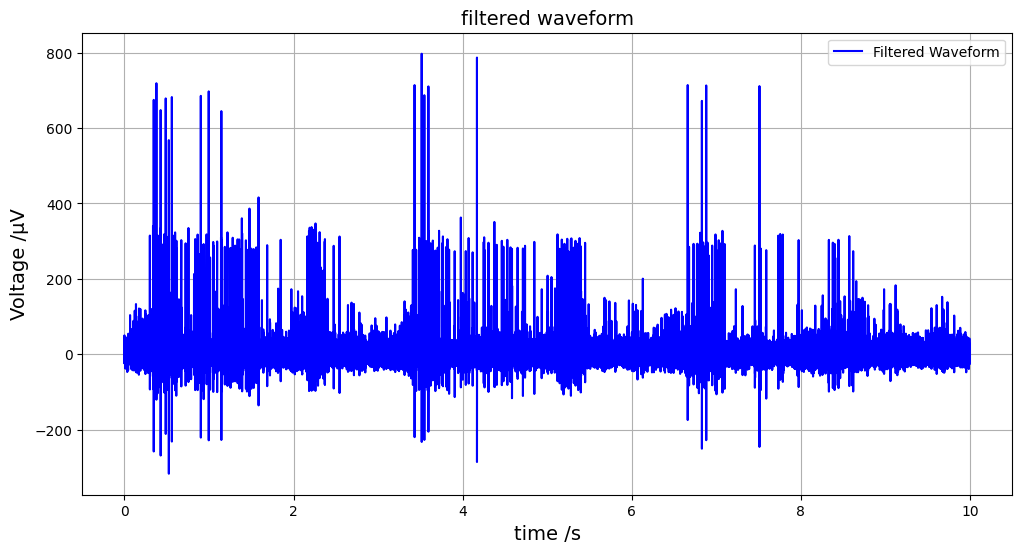

In [137]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.fft import fftshift  

# Plot with specified width and height
plt.figure(figsize=(12, 6))
plt.grid(True)

# ================= write your code below ================== #
# 定义采样参数
fs = 30000  # 采样率为30 kHz
nyquist = 0.5 * fs
low_cutoff = 250  # 截止频率为250 Hz

# 创建高通滤波器
def butter_highpass(cutoff, fs, order=5):
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return b, a

def highpass_filter(data, cutoff, fs, order=5):
    b, a = butter_highpass(cutoff, fs, order=order)
    y = filtfilt(b, a, data)
    return y


# 使用高通滤波器去除LFP
FilteredWaveform = highpass_filter(RealWaveform, low_cutoff, fs)
# 绘制滤波后的波形
plt.plot(np.arange(len(FilteredWaveform)) / fs, FilteredWaveform, label='Filtered Waveform', color='blue')
plt.legend()

# ========================================================== #

plt.xlabel('time /s', fontsize=14)
plt.ylabel('Voltage /μV', fontsize=14)
plt.title('filtered waveform', fontsize=14)
plt.legend()
plt.show()

**Question: (2.5 points) Was the low-frequency component removed?**

**Your answer:** No

# **(15 points)** spike detection

Set a threshold, Vthresh = 250µV , and determine all of the times that the signal crosses from
below to above the threshold. Plot the threshold as a line across your plot of the high-pass
filtered waveform (FilteredWaveform) from Problem 1.

Take 1 ms snippets of the waveform beginning 0.3 ms before each threshold crossing. Each
snippet should have 31 samples; the tenth sample should be less than Vthresh = 250µV ,
and the eleventh sample should be greater than Vthresh = 250µV . In a new figure, make a
“voltage versus time” plot containing the following:

* all of the threshold-crossing waveform snippets, and
* the threshold as a horizontal line.

Your result should look similar to Figure 3 from Lewicki’s review paper (see **Lewicki-
Network-98.pdf**), with the key difference that your plot should show multiple spike shapes
(instead of just one). You will also notice a few non-stereotyped traces resulting from either
different neurons spiking near the same time or noise exceeding threshold.

<Figure size 1200x600 with 0 Axes>

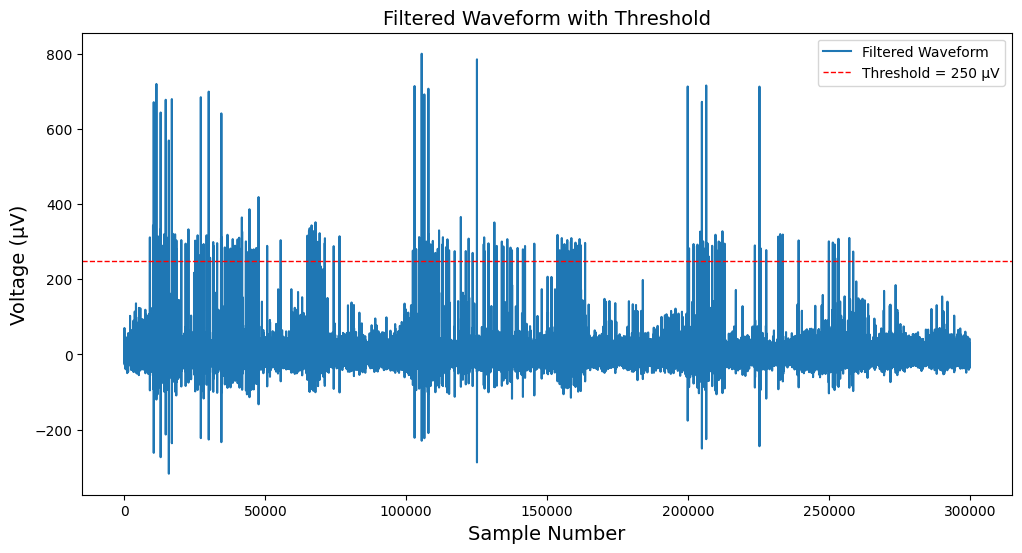

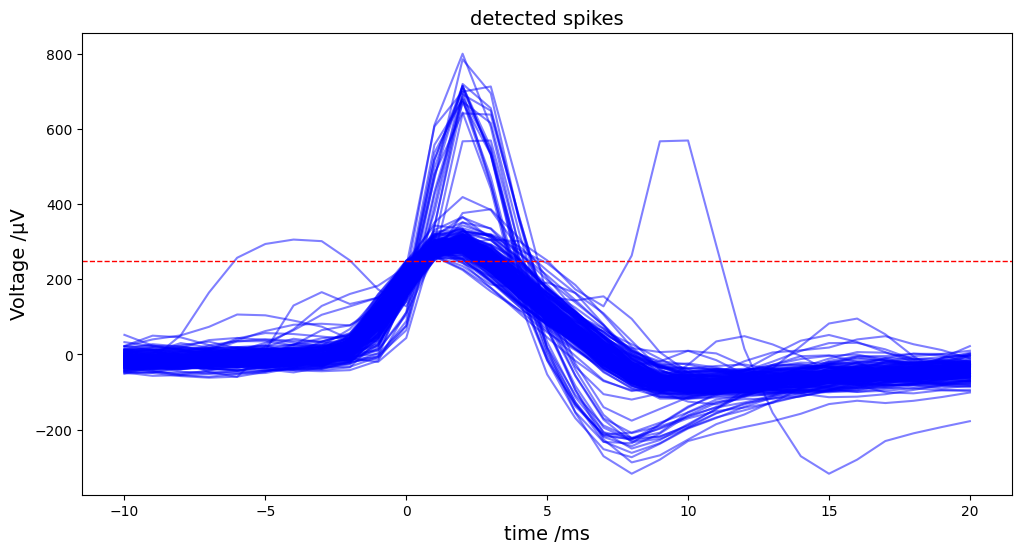

In [123]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

plt.figure(figsize=(12, 6))

# ================= write your code below ================== #
# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组

# 设置阈值
Vthresh = 250  # µV

# 找到信号从低于阈值到高于阈值的所有交叉时间
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]

# 提取每个交叉点周围的波形片段
num_samples = 31
segments = []
time_window = np.arange(-10, 21)  # 以样本为单位，对应于 -0.3 毫秒到 0.7 毫秒

for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)

# 将波形片段转换为数组（每行一个片段）
segments = np.array(segments)

# 绘制高通滤波波形和阈值线
plt.figure(figsize=(12, 6))
plt.plot(FilteredWaveform, label='Filtered Waveform')
plt.axhline(Vthresh, color='red', linestyle='--', linewidth=1, label='Threshold = 250 µV')
plt.xlabel('Sample Number', fontsize=14)
plt.ylabel('Voltage (µV)', fontsize=14)
plt.title('Filtered Waveform with Threshold', fontsize=14)
plt.legend()
plt.show()
# 绘制所有阈值交叉的波形片段
plt.figure(figsize=(12, 6))
for segment in segments:
    plt.plot(time_window, segment, color='blue', alpha=0.5)
plt.axhline(Vthresh, color='red', linestyle='--', linewidth=1, label='Threshold = 250 µV')
# ========================================================== #

plt.xlabel('time /ms', fontsize=14)
plt.ylabel('Voltage /μV', fontsize=14)
plt.title('detected spikes', fontsize=14)
plt.show()

# **(35 points)** Clustering with the K-means algorithm

Implement the EM algorithm for K-means clustering in Python (**IMPORTANT**: you need to write your own implementation rather than using existing packages), and use it to determine the neuron responsible for each recorded spike.

**(15 points)** Implement the EM algorithm in the cell below. The function's input and output values should match the comments at the beginning of the function. **In subsequent K-means clustering, you should use your own implemented em_algorithm function.**

In [124]:
def em_algorithm(spikes, initial_means, num_clusters=2, max_iter=100, tol=1e-4):
    """
    Perform the EM algorithm for K-means clustering.

    Parameters:
    spikes : np.ndarray, shape (dim, count)
        The dataset containing the spikes, where each column is a sample.
    
    initial_means : np.ndarray, shape (dim, num_clusters)
        Initial cluster centers.
    
    num_clusters : int, optional, default=2
        The number of clusters.
    
    max_iter : int, optional, default=100
        Maximum number of iterations.
    
    tol : float, optional, default=1e-4
        Tolerance to determine convergence.

    Returns:
    assignments : np.ndarray, shape (count, num_clusters)
        The responsibility matrix indicating cluster assignments.
    
    cluster_centers : np.ndarray, shape (dim, num_clusters)
        Final cluster centers.
    
    objective_values : list
        Objective function values for each iteration.
        
            num_samples = spikes.shape[1]
    dim = spikes.shape[0]
    """
    # ================= write your code below ================== #
    
    num_samples = spikes.shape[1]
    dim = spikes.shape[0]
    
    # 初始化
    cluster_centers = initial_means
    assignments = np.zeros((num_samples, num_clusters))
    objective_values = []
    
    for i in range(max_iter):
        # E-step: 更新分配
        for j in range(num_samples):
            distances = np.linalg.norm(spikes[:, j:j+1] - cluster_centers, axis=0)
            assignments[j, :] = np.zeros(num_clusters)
            assignments[j, np.argmin(distances)] = 1
        
        # M-step: 更新簇中心
        new_cluster_centers = np.zeros((dim, num_clusters))
        for k in range(num_clusters):
            assigned_samples = spikes[:, assignments[:, k] == 1]
            if len(assigned_samples) > 0:
                new_cluster_centers[:, k] = np.mean(assigned_samples, axis=1)

        # 检查收敛性
        if np.linalg.norm(new_cluster_centers - cluster_centers) < tol:
            break
        
        cluster_centers = new_cluster_centers
        
        # 计算目标函数值
        total_distance = 0.0
        for j in range(num_samples):
            total_distance += np.min(np.linalg.norm(spikes[:, j:j+1] - cluster_centers, axis=0)) ** 2
        objective_values.append(total_distance)

    # ========================================================== #

    return assignments, cluster_centers, objective_values

**(10 points)** Treat each snippet as a point $ x_n \in \mathbb{R}^D $, ($ n = 1, \ldots, N $), where $ D = 31 $ is the number of samples in each snippet, and $ N $ is the number of detected spikes. In this problem, we will assume that there are $K = 2 $ neurons contributing spikes to the recorded waveform. Initialize the cluster centers using **InitTwoClusters_1**.
For each cluster (k = 1, 2), **create a separate “voltage versus time” plot containing the following:**
* the cluster center $µ_k$ returned by K-means as a red waveform trace (i.e., the pro-
totypical action potential for the kth neuron),
* all of the waveform snippets assigned to the kth neuron, and
* the threshold as a horizontal line.

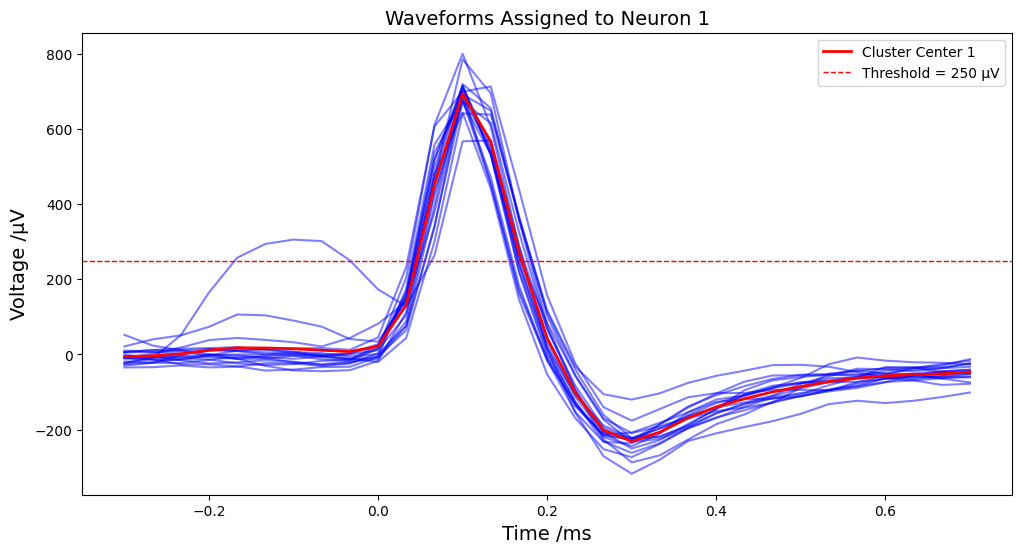

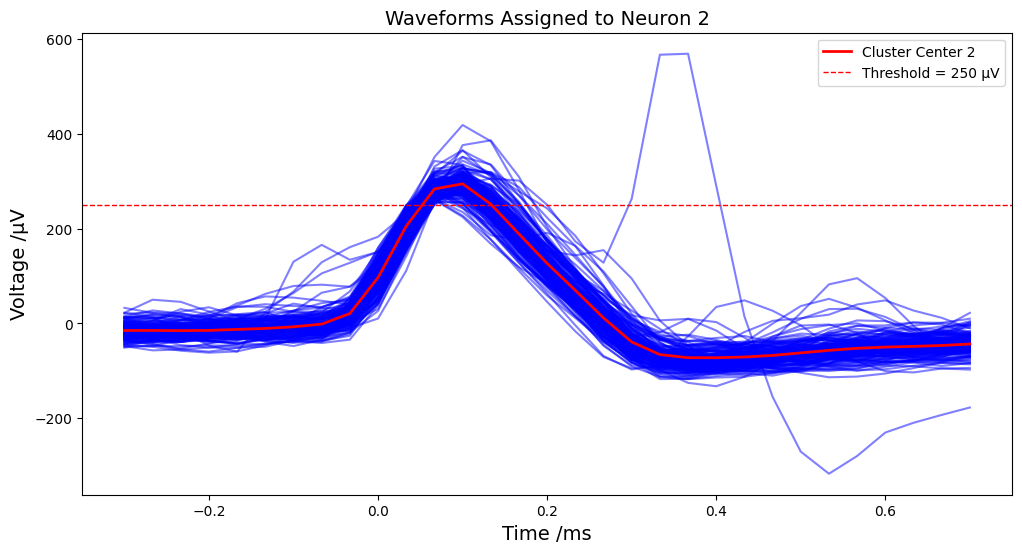

In [125]:
# ================= write your code below ================== #
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组
initTwoClusters_1 = data['initTwoClusters_1']

# 设置阈值
Vthresh = 250  # µV

# 确定信号从低于阈值到高于阈值的所有交叉时间
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]

# 提取每个交叉点前0.3毫秒（10个样本）和后0.7毫秒（21个样本）的波形片段
num_samples = 31
segments = []
for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)

# 将波形片段转换为数组
segments = np.array(segments)



# 运行K-means聚类
assignments, cluster_centers, objective_values = em_algorithm(segments.T, initTwoClusters_1, num_clusters=2)

# 绘制结果
time_window = np.linspace(-0.3, 0.7, num_samples)  # 毫秒

for k in range(2):
    plt.figure(figsize=(12, 6))
    for i, segment in enumerate(segments):
        if assignments[i, k] == 1:
            plt.plot(time_window, segment, 'b', alpha=0.5)
    plt.plot(time_window, cluster_centers[:, k], 'r', linewidth=2, label=f'Cluster Center {k+1}')
    plt.axhline(Vthresh, color='red', linestyle='--', linewidth=1, label='Threshold = 250 µV')
    plt.xlabel('Time /ms', fontsize=14)
    plt.ylabel('Voltage /μV', fontsize=14)
    plt.title(f'Waveforms Assigned to Neuron {k+1}', fontsize=14)
    plt.legend()
    plt.show()
    

**(5 points)** Plot the objective function J (which is the `objective_values` returned by the `em_algorithm` function) versus iteration number (as in Figure 9.2 in PRML).

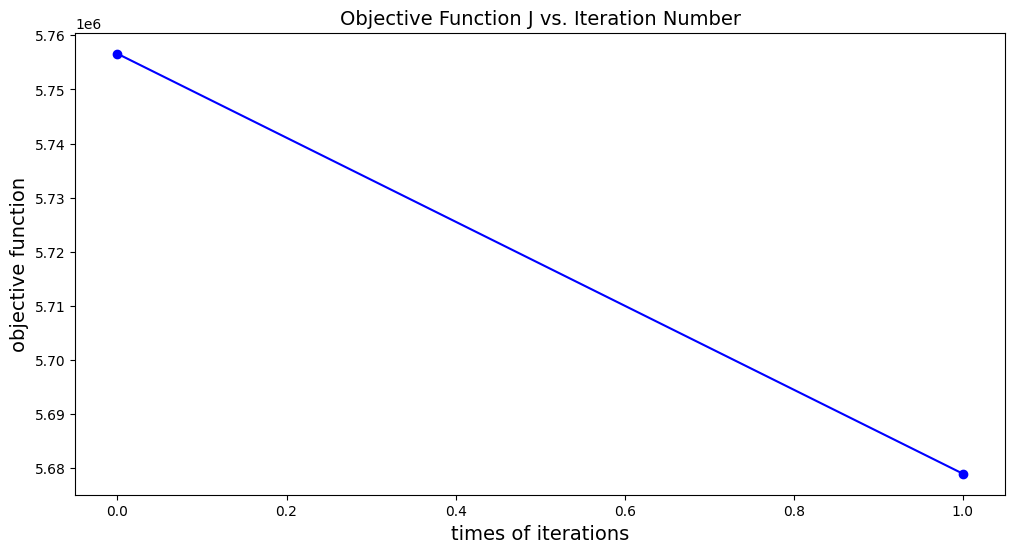

In [126]:
# ================= write your code below ================== #
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组
InitTwoClusters_1 = data['initTwoClusters_1']

# 设置阈值
Vthresh = 250  # µV

# 确定信号从低于阈值到高于阈值的所有交叉时间
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]

# 提取每个交叉点前0.3毫秒（10个样本）和后0.7毫秒（21个样本）的波形片段
num_samples = 31
segments = []
for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)

segments = np.array(segments)

# 使用 `initTwoClusters_1` 初始化的簇中心运行K-means聚类
assignments, cluster_centers, objective_values = em_algorithm(segments.T, InitTwoClusters_1, num_clusters=2)

# 绘制目标函数 J 对迭代次数的图
plt.figure(figsize=(12, 6))
plt.plot(objective_values, marker='o', linestyle='-', color='b')
plt.xlabel('times of iterations', fontsize=14)
plt.ylabel('objective function', fontsize=14)
plt.title('Objective Function J vs. Iteration Number', fontsize=14)
plt.show()
# ========================================================== #

# hints: you should use the bleow code to plot the results
# plt.xlabel('times of iterations', fontsize=14)
# plt.ylabel('objective function', fontsize=14)

**Question：(5 points) How many iterations did it take for K-means to converge?**

**Your Answer:** 2

# **(15 points)** Clustering with different initilization

As discussed in class, K-means guarantees convergence to a local optimum.
Thus, it is possible to converge to different local optima with different initializations. Provide your cluster plot and lost function plot where the cluster centers are initialized using **InitTwoClusters_2**. 

**(5 points)** Initialize the cluster centers using **InitTwoClusters_2**.
For each cluster (k = 1, 2), **create a separate “voltage versus time” plot containing the following:**
* the cluster center $µ_k$ returned by K-means as a red waveform trace (i.e., the pro-
totypical action potential for the kth neuron),
* all of the waveform snippets assigned to the kth neuron, and
* the threshold as a horizontal line.

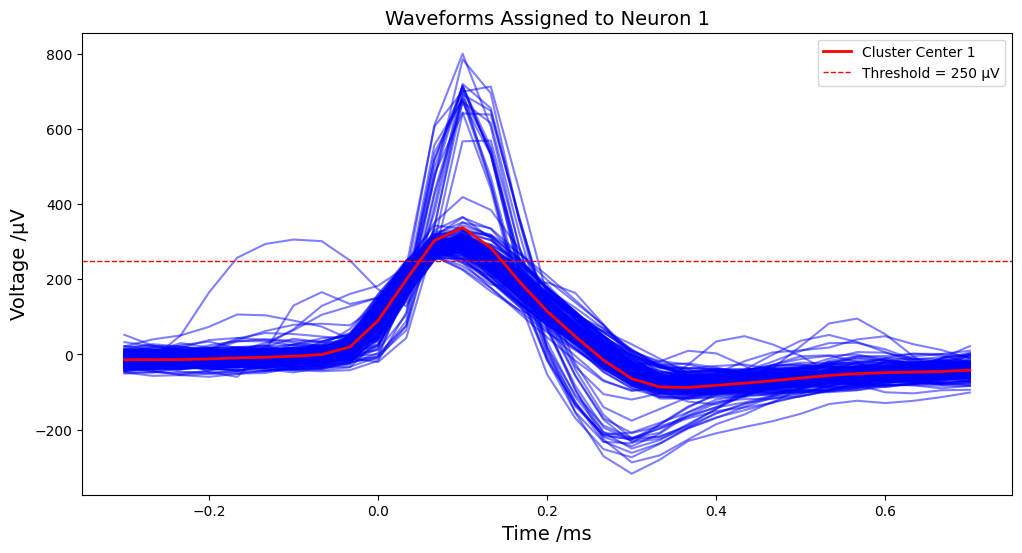

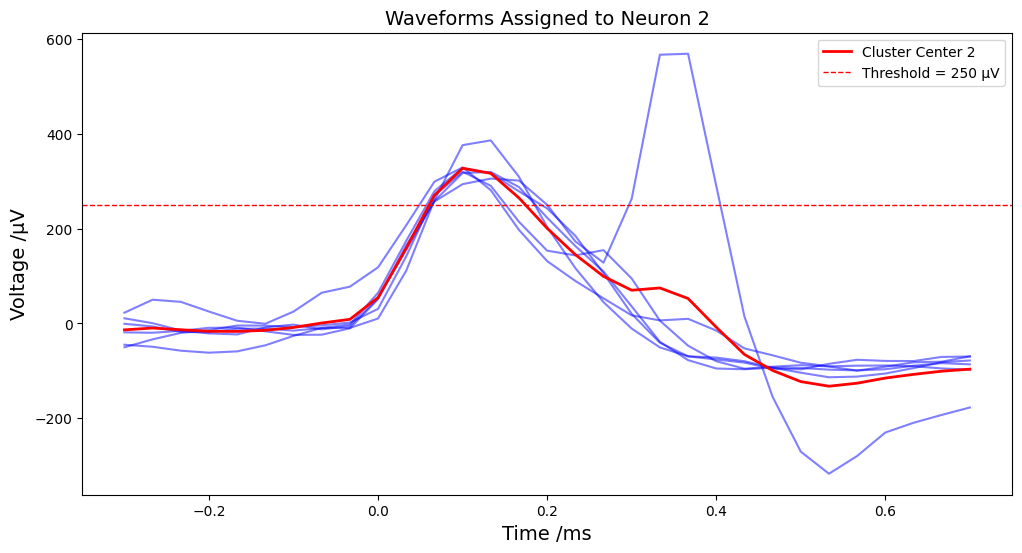

In [127]:
# ================= write your code below ================== #
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组
initTwoClusters_2 = data['initTwoClusters_2']

# 设置阈值
Vthresh = 250  # µV

# 确定信号从低于阈值到高于阈值的所有交叉时间
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]

# 提取每个交叉点前0.3毫秒（10个样本）和后0.7毫秒（21个样本）的波形片段
num_samples = 31
segments = []
for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)

# 将波形片段转换为数组
segments = np.array(segments)



# 运行K-means聚类
assignments, cluster_centers, objective_values = em_algorithm(segments.T, initTwoClusters_2, num_clusters=2)

# 绘制结果
time_window = np.linspace(-0.3, 0.7, num_samples)  # 毫秒

for k in range(2):
    plt.figure(figsize=(12, 6))
    for i, segment in enumerate(segments):
        if assignments[i, k] == 1:
            plt.plot(time_window, segment, 'b', alpha=0.5)
    plt.plot(time_window, cluster_centers[:, k], 'r', linewidth=2, label=f'Cluster Center {k+1}')
    plt.axhline(Vthresh, color='red', linestyle='--', linewidth=1, label='Threshold = 250 µV')
    plt.xlabel('Time /ms', fontsize=14)
    plt.ylabel('Voltage /μV', fontsize=14)
    plt.title(f'Waveforms Assigned to Neuron {k+1}', fontsize=14)
    plt.legend()
    plt.show()
    
# hints: you should use the bleow code to plot the results
# plt.xlabel('time /ms', fontsize=14)
# plt.ylabel('Voltage /μV', fontsize=14)

**(5 points)** Plot the objective function J (which is the `objective_values` returned by the `em_algorithm` function) versus iteration number (as in Figure 9.2 in PRML).

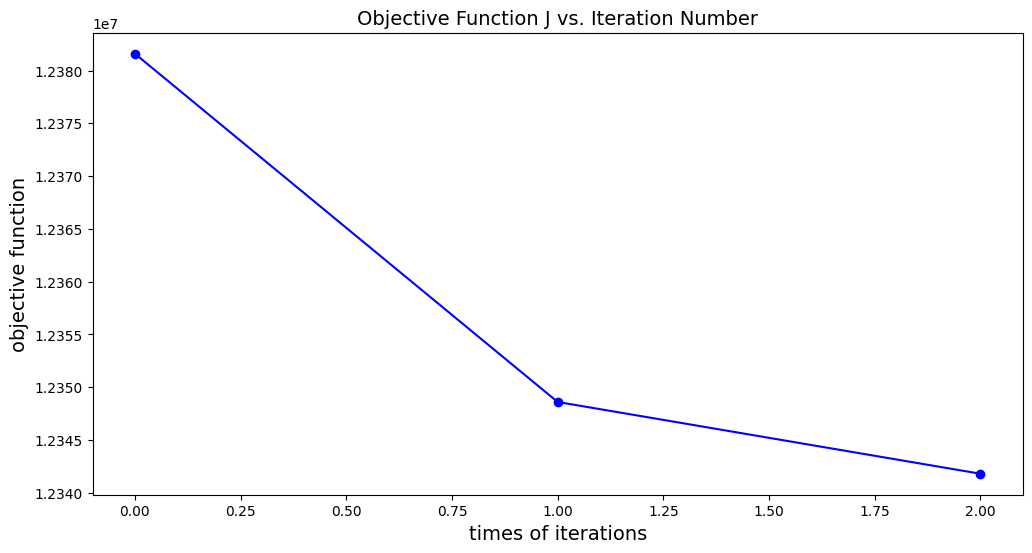

In [128]:
# ================= write your code below ================== #
import numpy as np
import matplotlib.pyplot as plt
import scipy.io

# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组
InitTwoClusters_2 = data['initTwoClusters_2']

# 设置阈值
Vthresh = 250  # µV

# 确定信号从低于阈值到高于阈值的所有交叉时间
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]

# 提取每个交叉点前0.3毫秒（10个样本）和后0.7毫秒（21个样本）的波形片段
num_samples = 31
segments = []
for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)

segments = np.array(segments)

# 使用 `InitTwoClusters_1` 初始化的簇中心运行K-means聚类
assignments, cluster_centers, objective_values = em_algorithm(segments.T, InitTwoClusters_2, num_clusters=2, max_iter=100)

# 绘制目标函数 J 对迭代次数的图
plt.figure(figsize=(12, 6))
plt.plot(objective_values, marker='o', linestyle='-', color='b')
plt.xlabel('times of iterations', fontsize=14)
plt.ylabel('objective function', fontsize=14)
plt.title('Objective Function J vs. Iteration Number', fontsize=14)
plt.show()
# ========================================================== #

# hints: you should use the bleow code to plot the results
# plt.xlabel('times of iterations', fontsize=14)
# plt.ylabel('objective function', fontsize=14)

**Question: (5 points) Is the local optimum found here the same or different as that found in the initialzed with `InitTwoClusters_1`?**

**Your Answer:** different

# **(35 points)** determining number of clusters by silhouette score

With real data, we don’t typically know how many neurons contribute spikes to a given
recorded waveform. We will soon discuss in class how to infer the number of neurons from
the data, a procedure which typically requires running the clustering algorithm on the same
data for different values of K. 

Next, we will implement a function to calculate the silhouette coefficient and determine how to select the appropriate number of clusters based on the silhouette coefficient. With the given initial values, you need to plot the silhouette diagrams for $k=2$, $k=3$, and $k=4$, as well as the PCA-based cluster visualization images for each.

**(10 points)** Implement a function to calculate the silhouette coefficient. Ensure that the function's input and output values match the comments in the function.

In [129]:
def silhouette_score(X, labels):
    """
    Calculate the silhouette score for a dataset.

    Parameters:
    X : array-like, shape (n_samples, n_features)
        The dataset, where each row is a sample.
    
    labels : array-like, shape (n_samples,)
        The cluster labels for each sample.

    Returns:
    float
        The mean silhouette score for the dataset.
    """
    # ================= write your code below ================== #
    # 获取样本数量
    n_samples = X.shape[0]
    unique_labels = np.unique(labels)
    n_clusters = len(unique_labels)
    
    if n_clusters <= 1:
        return 0.0  # 不适用于单个簇或无簇情况
    
    # 初始化轮廓系数数组
    silhouette_scores = np.zeros(n_samples)
    
    for i in range(n_samples):
        # 获取当前样本所属的簇
        current_label = labels[i]
        current_cluster = X[labels == current_label]

        # 计算 a(i)，即样本 i 到其所属簇内其他样本的平均距离
        if len(current_cluster) > 1:
            a_i = np.mean([np.linalg.norm(X[i] - x) for x in current_cluster if not np.array_equal(x, X[i])])
        else:
            a_i = 0.0
        
        # 计算 b(i)，即样本 i 到最近簇的平均距离
        b_i = np.inf
        for label in unique_labels:
            if label != current_label:
                other_cluster = X[labels == label]
                distance = np.mean([np.linalg.norm(X[i] - x) for x in other_cluster])
                if distance < b_i:
                    b_i = distance
        
        # 计算样本 i 的轮廓系数
        silhouette_scores[i] = (b_i - a_i) / max(a_i, b_i)
    
    # 计算数据集的平均轮廓系数
    mean_silhouette_score = np.mean(silhouette_scores)
    
    return mean_silhouette_score

# 示例使用
# 假设 X 是一个数据集，labels 是相应的簇标签
# silhouette = silhouette_score(X, labels)
# print("Silhouette Coefficient:", silhouette)
    # ========================================================== #
    

**(5 points)** Plot the silhouette diagram and PCA-based cluster visualization for $K=2$ using `initTwoCluster_2`, ensuring they match the images on slide 37 (your colors may vary). You can perform PCA by using `from sklearn.decomposition import PCA`. (You should provide two images, including **silhouette plot** and **PCA-based cluster visualization**.)

Silhouette score: 0.41777760917189666


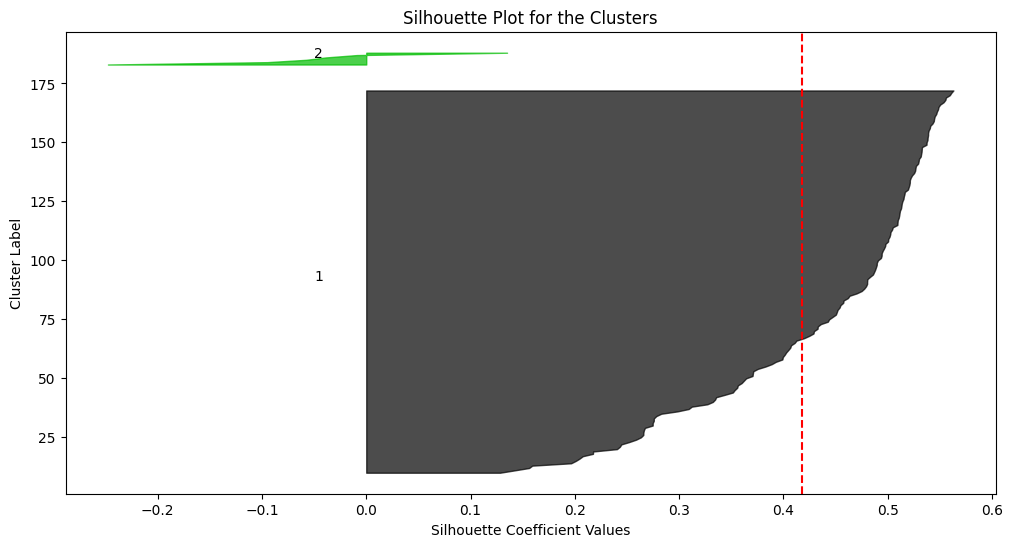

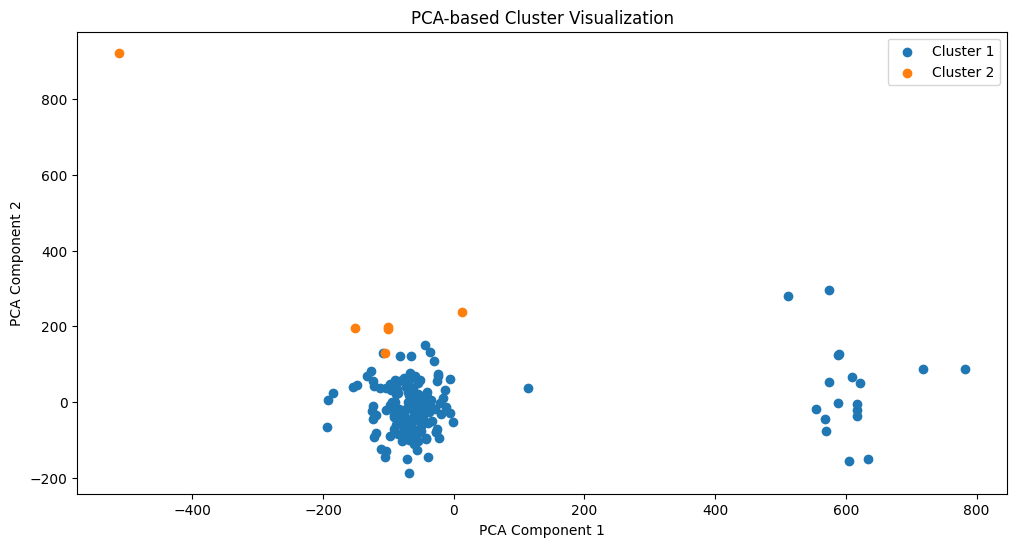

In [130]:
# ================= write your code below ================== #

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score


# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组
initTwoClusters_2 = data['initTwoClusters_2']

# 设置阈值
Vthresh = 250  # µV

# 确定信号从低于阈值到高于阈值的所有交叉时间
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]

# 提取每个交叉点前0.3毫秒（10个样本）和后0.7毫秒（21个样本）的波形片段
num_samples = 31
segments = []
for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)

segments = np.array(segments)

# 使用 `InitTwoClusters_2` 初始化的簇中心运行K-means聚类
assignments, cluster_centers, objective_values = em_algorithm(segments.T, initTwoClusters_2, num_clusters=2)


# 获取簇标签
labels = np.argmax(assignments, axis=1)

# 计算轮廓系数
silhouette_avg = silhouette_score(segments, labels)
print(f'Silhouette score: {silhouette_avg}')

# 绘制轮廓图
sample_silhouette_values = silhouette_samples(segments, labels)
plt.figure(figsize=(12, 6))
y_lower = 10

for i in range(2):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / 2)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i+1))
    
    y_lower = y_upper + 10

plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.title("Silhouette Plot for the Clusters")
plt.show()

# PCA降维
pca = PCA(n_components=2)
transformed_data = pca.fit_transform(segments)

# 绘制PCA降维后的聚类结果
plt.figure(figsize=(12, 6))
for label in range(2):
    plt.scatter(transformed_data[labels == label, 0], transformed_data[labels == label, 1], label=f'Cluster {label+1}')

plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA-based Cluster Visualization')
plt.legend()
plt.show()
# ========================================================== #

**Question：(5 points) What information can you gather from the silhouette plot for $k=2$ using `initTwoCluster2`?**

**Your Answer:** Silhouette score: 0.41777760917189666

**(5 points)** Plot the silhouette diagram and PCA-based cluster visualization for $K=3$ using `initThreeClusters`, ensuring they match the images on slide 37 (your colors may vary). You can perform PCA by using `from sklearn.decomposition import PCA`. (You should provide two images, including **silhouette plot** and **PCA-based cluster visualization**.)

Silhouette score: 0.24032300319771552


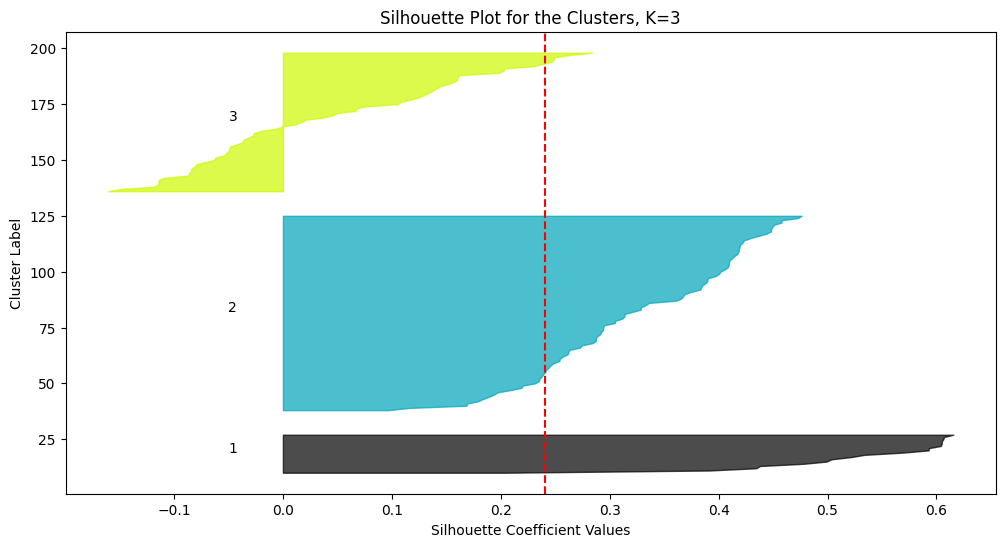

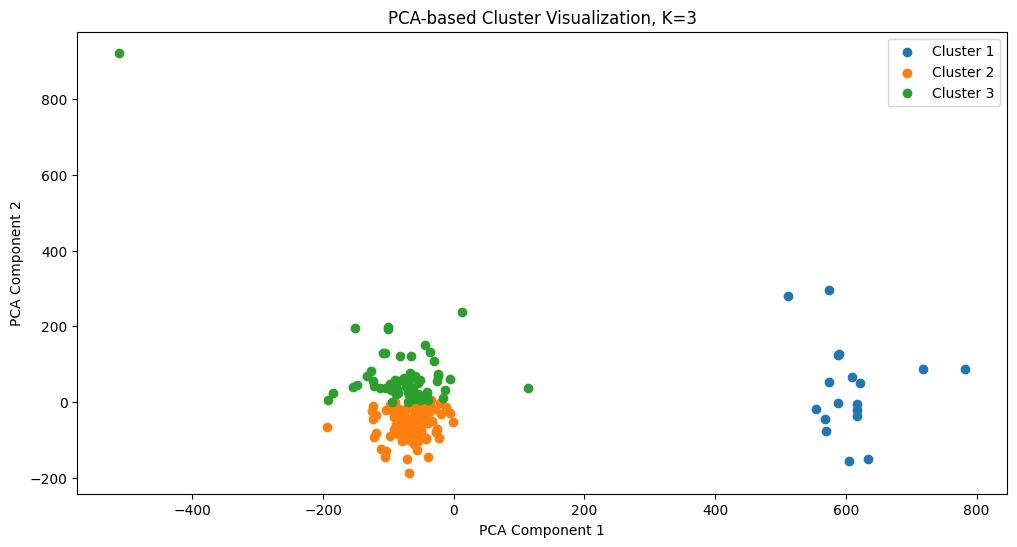

In [135]:
# ================= write your code below ================== #

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples


# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组
InitThreeClusters = data['initThreeClusters']

# 提取波形片段
Vthresh = 250  # µV
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]
num_samples = 31
segments = []
for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)
segments = np.array(segments).T

# 使用 `InitThreeClusters` 初始化的簇中心运行K-means聚类
assignments, cluster_centers, objective_values = em_algorithm(segments, InitThreeClusters, num_clusters=3)
labels = np.argmax(assignments, axis=1)

# 计算轮廓系数
silhouette_avg = silhouette_score(segments.T, labels)
sample_silhouette_values = silhouette_samples(segments.T, labels)
print(f'Silhouette score: {silhouette_avg}')

# 绘制轮廓图
plt.figure(figsize=(12, 6))
y_lower = 10

for i in range(3):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / 3)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i+1))
    
    y_lower = y_upper + 10

plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.title("Silhouette Plot for the Clusters, K=3")
plt.show()

# PCA降维和聚类结果可视化
pca = PCA(n_components=2)
transformed_data = pca.fit_transform(segments.T)

plt.figure(figsize=(12, 6))
for label in range(3):
    plt.scatter(transformed_data[labels == label, 0], transformed_data[labels == label, 1], label=f'Cluster {label+1}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA-based Cluster Visualization, K=3')
plt.legend()
plt.show()

# ========================================================== #

**(5 points)** Plot the **silhouette plot** and **PCA-based cluster visualization** for $K=4$ using `initFourClusters`, ensuring they match the images on slide 37 (your colors may vary). You can perform PCA by using `from sklearn.decomposition import PCA`. (You should provide two images, including **silhouette plot** and **PCA-based cluster visualization**.)

Silhouette score: 0.23685424371499136


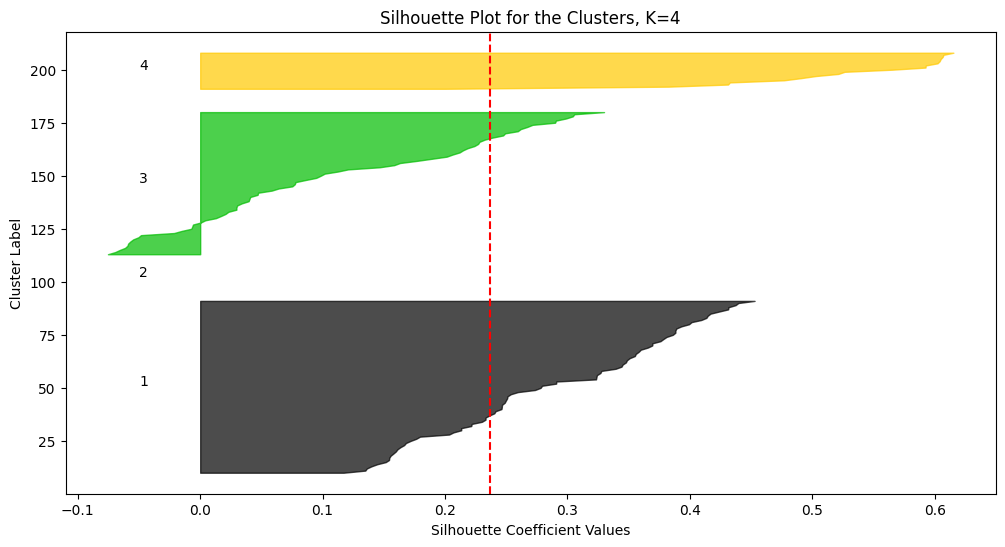

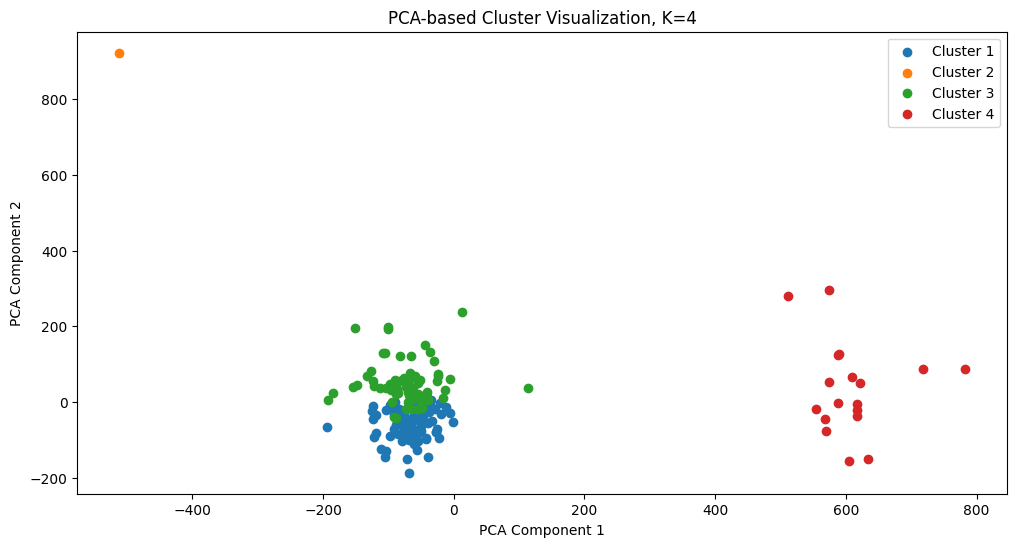

In [136]:
# ================= write your code below ================== #

import numpy as np
import matplotlib.pyplot as plt
import scipy.io
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

def em_algorithm(spikes, initial_means, num_clusters=4, max_iter=100, tol=1e-4):
    """
    实施K-means聚类的EM算法

    参数:
    spikes : np.ndarray, shape (dim, count)
        包含尖峰数据的数据集，每一列是一个样本。
    
    initial_means : np.ndarray, shape (dim, num_clusters)
        初始簇中心。
    
    num_clusters : int, optional, default=4
        簇的数量。
    
    max_iter : int, optional, default=100
        最大迭代次数。
    
    tol : float, optional, default=1e-4
        判断收敛的容差。

    返回:
    assignments : np.ndarray, shape (count, num_clusters)
        表示簇分配的责任矩阵。
    
    cluster_centers : np.ndarray, shape (dim, num_clusters)
        最终簇中心。
    
    objective_values : list
        每次迭代的目标函数值。
    """
    
    num_samples = spikes.shape[1]
    dim = spikes.shape[0]
    
    # 初始化
    cluster_centers = initial_means
    assignments = np.zeros((num_samples, num_clusters))
    objective_values = []
    
    for i in range(max_iter):
        # E-step: 更新分配
        for j in range(num_samples):
            distances = np.linalg.norm(spikes[:, j:j+1] - cluster_centers, axis=0)
            assignments[j, :] = np.zeros(num_clusters)
            assignments[j, np.argmin(distances)] = 1
        
        # M-step: 更新簇中心
        new_cluster_centers = np.zeros((dim, num_clusters))
        for k in range(num_clusters):
            assigned_samples = spikes[:, assignments[:, k] == 1]
            if len(assigned_samples) > 0:
                new_cluster_centers[:, k] = np.mean(assigned_samples, axis=1)

        # 检查收敛
        if np.linalg.norm(new_cluster_centers - cluster_centers) < tol:
            break
        
        cluster_centers = new_cluster_centers
        
        # 计算目标函数值
        total_distance = 0.0
        for j in range(num_samples):
            total_distance += np.min(np.linalg.norm(spikes[:, j:j+1] - cluster_centers, axis=0)) ** 2
        objective_values.append(total_distance)

    return assignments, cluster_centers, objective_values

# 加载数据
data = scipy.io.loadmat('ps2_data.mat')
FilteredWaveform = data['FilteredWaveform'].flatten()  # 展平为一维数组
InitFourClusters = data['initFourClusters']

# 提取波形片段
Vthresh = 250  # µV
crossing_points = np.where((FilteredWaveform[:-1] < Vthresh) & (FilteredWaveform[1:] > Vthresh))[0]
num_samples = 31
segments = []
for cp in crossing_points:
    if cp >= len(FilteredWaveform) - 21 or cp < 10:
        continue
    segment = FilteredWaveform[cp - 10: cp + 21]
    if len(segment) == num_samples:
        segments.append(segment)
segments = np.array(segments).T

# 使用 `InitFourClusters` 初始化的簇中心运行K-means聚类
assignments, cluster_centers, objective_values = em_algorithm(segments, InitFourClusters, num_clusters=4)
labels = np.argmax(assignments, axis=1)

# 计算轮廓系数
silhouette_avg = silhouette_score(segments.T, labels)
sample_silhouette_values = silhouette_samples(segments.T, labels)
print(f'Silhouette score: {silhouette_avg}')

# 绘制轮廓图
plt.figure(figsize=(12, 6))
y_lower = 10

for i in range(4):
    ith_cluster_silhouette_values = sample_silhouette_values[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / 4)
    plt.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i+1))
    
    y_lower = y_upper + 10

plt.xlabel("Silhouette Coefficient Values")
plt.ylabel("Cluster Label")
plt.axvline(x=silhouette_avg, color="red", linestyle="--")
plt.title("Silhouette Plot for the Clusters, K=4")
plt.show()

# PCA降维和聚类结果可视化
pca = PCA(n_components=2)
transformed_data = pca.fit_transform(segments.T)

plt.figure(figsize=(12, 6))
for label in range(4):
    plt.scatter(transformed_data[labels == label, 0], transformed_data[labels == label, 1], label=f'Cluster {label+1}')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA-based Cluster Visualization, K=4')
plt.legend()
plt.show()

# ========================================================== #

**Question：(5 points) Provide the silhouette scores for $K=2, 3, 4$. Based on these scores, choose the optimal number of clusters and explain your reasoning.**

**Your Answer：** 2
